# Análisis del Modelo 3D

In [ ]:
# Lo primero que tenemos que hacer es importar las librerías que necesitamos
# para poder realizar el análisis del modelo
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sympy as sp
from operator import index
from scipy.integrate import solve_ivp # Initial Values Solver --> resolver ODEs

## 1. Definimos el modelo 3D

El sistema de ecuaciones diferenciales es:

\begin{align*}
\frac{dx}{dt} &= \lambda x \left(1 - \frac{x + y}{K} \right) - \beta x v \\
\frac{dy}{dt} &= \beta x v - \gamma y \\
\frac{dv}{dt} &= b \gamma y - \beta x v - \delta v, \quad x+y \leq K, \quad v \leq \frac{b \gamma K}{\delta}
\end{align*}

In [ ]:
# Podemos definir el modelo como una función para poderlo llamar más adelante
# Modelo 3D de viroterapia
def modelo3D(t, z, λ, K, β, γ, b, δ):
  x, y, v = z

  # Restricción 1: Control logístico (x + y no puede superar K)
  total = x + y
  if total > K:
      factor = K / total
      x *= factor
      y *= factor

  # Restricción 2: Limitar v al máximo permitido
  v_max = b * γ * K / δ
  v = np.clip(v, 0, v_max)

  # Sistema dinámico simplificado (Tian 2011: βv = βy = 0)
  dx = λ * x * (1 - (x + y) / K) - β * x * v
  dy = β * x * v - γ * y
  dv = -β * x * v + b * γ * y - δ * v

  return [dx, dy, dv]

def modelo3D_sym(t, z, λ, K, β, γ, b, δ):
  x, y, v = z

  # En sympy ya tomamos las variables como positivas
  # Sistema dinámico simplificado (Tian 2011: βv = βy = 0)
  dx = λ * x * (1 - (x + y) / K) - β * x * v
  dy = β * x * v - γ * y
  dv = -β * x * v + b * γ * y - δ * v

  return [dx, dy, dv]

**Parámetro del modelo:**

*   **x**: células tumorales sin tratar
*   **y**: células tumorales infectadas
*   **v**: virus
*   **t**: tiempo (obligatorio para solve_ivp)
*   **z**: vector de estado
*   **l**: λ (lambda) - tasa de crecimiento de células sin infectar
*   **K**: K (carga máxima de células tumorales no infectadas)
*   **B**: β (beta) - tasa de infección viral
*   **g**: γ (gamma) - tasa de lisis de células infectadas
*   **b**: tamaño del estallido viral
*   **d**: δ (delta) - tasa de eliminación de virus

## 2. Puntos fijos

Para calcular los puntos fijos del sistema, se debe igualar cada una de las ecuaciones diferenciales a cero. Necesitamos saber dónde se anulan las derivadas.

Puntos fijos del modelo 3D:

$$ \begin{align*}
\dot{\text{x}} &= \lambda \cdot x \left(1 - \frac{x + y}{K} \right) - \beta \cdot x \cdot v = 0 \\
\dot{\text{y}} &= \beta \cdot x \cdot v - \gamma \cdot y = 0 \\
\dot{\text{v}} &= -\beta \cdot x \cdot v + b \cdot \gamma \cdot y - \delta \cdot v = 0
\end{align*} $$


In [ ]:
# Variables
x, y, v = sp.symbols('x y v', real=True, nonnegative=True)

# Parámetros
λ, δ, β, b, K, γ = sp.symbols('λ δ β b K γ', real=True, positive=True)

# Definimos el modelo simbólico con las vairables y los parámetros
model_simb = modelo3D_sym(0, [x, y, v], λ, K, β, γ, b, δ)

# Comprobamos que las ecuaciones que conforman el modelo son las correctas
for i in range(3):
    print(f"Eq{i+1}:")
    display(sp.Eq(model_simb[i], 0))

# Resolvemos el modelo para calcular los puntos fijos simbólicos
puntos_fijos_simb = sp.solve(model_simb, (x, y, v), dict=True)

print()
print('Número de puntos fijos:', len(puntos_fijos_simb)) # Número total de puntos fijos

for pf_simb in puntos_fijos_simb:
  print(f"Punto Fijo Simb:", pf_simb)

print()

# Definimos los parámetros con los valores correspondientes
params = {λ:0.36, β:0.11, γ:1, δ:0.44, b:28, K:1}
λ, δ, β, b, K, γ = 0.36, 0.44, 0.11, 28, 1, 1

# Definimos el modelo sustituyendo los valores de los parámetros
model = modelo3D_sym(0, [x, y, v], λ, K, β, γ, b, δ)

# Volvemos a calcular los puntos fijos con los valores que hemos fijado
puntos_fijos = sp.solve(model, (x, y, v), dict=True)

for pf in puntos_fijos:
  print("Punto Fijo Num:", pf)

Eq1:


Eq(-v*x*β + x*λ*(1 - (x + y)/K), 0)

Eq2:


Eq(v*x*β - y*γ, 0)

Eq3:


Eq(b*y*γ - v*x*β - v*δ, 0)


Número de puntos fijos: 3
Punto Fijo Simb: {v: 0, x: 0, y: 0}
Punto Fijo Simb: {v: 0, x: K, y: 0}
Punto Fijo Simb: {v: γ*λ*(K*b*β - K*β - δ)/(β*(K*b*β*γ - K*β*γ + δ*λ)), x: δ/(β*(b - 1)), y: δ*λ*(K*b*β - K*β - δ)/(β*(b - 1)*(K*b*β*γ - K*β*γ + δ*λ))}

Punto Fijo Num: {v: 0.0, x: 0.0, y: 0.0}
Punto Fijo Num: {v: 0.0, x: 1.00000000000000, y: 0.0}
Punto Fijo Num: {v: 2.64672036823936, x: 0.148148148148148, y: 0.0431317393342710}


Punto libre de infección y tumor:

  $ E_0 = (x, y, v) = (0, 0, 0) $

Punto con tumor pero sin virus:

  $ E_K = (x, y, v) = (1, 0, 0) $

Punto endémico (todos positivos):

$ E_* = (x, y, v) \approx (0.1481, 0.04313, 2.6467) $

Ahora que tenemos los puntos fijos podemos analizar su estabilidad para ver son puntos fijos estables o inestables. Esto lo vamos a hacer mediante el método de Routh-Hurwitz. El método de Routh te permite saber si los autovalores tienen parte real negativa (es decir, si el sistema es estable) sin tener que calcular los autovalores. Solo necesitas mirar los coeficientes del polinomio.


## 3. Análisis de estabilidad: Routh-Hurwitz

**El Polinomio Característico**

Todo empieza con la matriz Jacobiana ($J$) evaluada en tu punto fijo. Para encontrar los autovalores, planteas la ecuación:$$\det(J - \lambda I) = 0$$Esto te dará un polinomio. Como tu sistema tiene 3 variables ($x, y, v$), te saldrá un polinomio de grado 3:$$P(\lambda) = a_3 \lambda^3 + a_2 \lambda^2 + a_1 \lambda + a_0 = 0$$

**Las Reglas de Routh-Hurwitz (Para n=3)**

Para que el punto fijo sea estable, se tienen que cumplir condiciones específicas sobre esos coeficientes $a_2, a_1, a_0$. Si tienes el polinomio $$\lambda^3 + a_2 \lambda^2 + a_1 \lambda + a_0 = 0$$ el criterio dice que el sistema es estable si y solo si se cumplen **todas** estas condiciones:

1. Todos los coeficientes deben ser positivos:$$a_2 > 0, \quad a_1 > 0, \quad a_0 > 0$$

2. Condición del producto (La más importante): El producto de los coeficientes del medio debe ser mayor que el término independiente:$$a_2 \cdot a_1 > a_0$$

Cuando tienes una matriz Jacobiana $J$ de $3 \times 3$, su polinomio característico (el que te da los autovalores $\lambda$) siempre tiene esta estructura específica:$$P(\lambda) = \lambda^3 - \underbrace{\text{Tr}(J)}_{a_2} \lambda^2 + \underbrace{M_2(J)}_{a_1} \lambda - \underbrace{\text{Det}(J)}_{a_0} = 0$$

* $a_2 = - {\text{Tr}(J)}$
* $a_1 = {M_2(J)}$
* $a_0 = - \text{Det}(J)$
* Normlamente $a_3$ es 1

Las condiciones ahora se traducen en:

1. La Traza Negativa:
$$\text{Tr}(J) < 0 → a_2 > 0$$

2. La condición del producto
$$\text{Tr}(J) M_2(J) < \text{Det}(J) → a_2 \cdot a_1 > a_0$$

### 3.1 Cálculo de la Jacobiana

In [ ]:
# Jacobiana simbólica
J = sp.Matrix(model_simb).jacobian((x, y, v))
print("Jacobiana: \n")
J

Jacobiana: 



Matrix([
[-v*β + λ*(1 - (x + y)/K) - x*λ/K, -x*λ/K,     -x*β],
[                             v*β,     -γ,      x*β],
[                            -v*β,    b*γ, -x*β - δ]])

In [ ]:
print('Jacobiana evaluada en los puntos fijos (sin sustituir): \n')
J = sp.Matrix(model_simb).jacobian((x, y, v))
display(J)

print('\n', puntos_fijos_simb[0],'\n')
J_0 = J.subs(puntos_fijos_simb[0]) # E_0
display(J_0)

print('\n', puntos_fijos_simb[1], '\n')
J_1 = J.subs(puntos_fijos_simb[1]) # E_K
display(J_1)

print('\n', puntos_fijos_simb[2], '\n')
J_2 = J.subs(puntos_fijos_simb[2]) # E_*
display(J_2)

print()
print('Jacobiana evaluada en los puntos fijos (sustituido): \n')
J_num = sp.Matrix(model).jacobian((x, y, v))
display(J_num)

print('\n', puntos_fijos[0],'\n')
J_num_0 = J_num.subs(puntos_fijos[0]) # E_0
display(J_num_0)

print('\n', puntos_fijos[1], '\n')
J_num_1 = J_num.subs(puntos_fijos[1]) # E_K
display(J_num_1)

print('\n', puntos_fijos[2], '\n')
J_num_2 = J_num.subs(puntos_fijos[2]) # E_*
display(J_num_2)

Jacobiana evaluada en los puntos fijos (sin sustituir): 



Matrix([
[-v*β + λ*(1 - (x + y)/K) - x*λ/K, -x*λ/K,     -x*β],
[                             v*β,     -γ,      x*β],
[                            -v*β,    b*γ, -x*β - δ]])


 {v: 0, x: 0, y: 0} 



Matrix([
[λ,   0,  0],
[0,  -γ,  0],
[0, b*γ, -δ]])


 {v: 0, x: K, y: 0} 



...

Matrix([
[0.36,  0,     0],
[   0, -1,     0],
[   0, 28, -0.44]])


 {v: 0.0, x: 1.00000000000000, y: 0.0} 



Matrix([
[-0.36, -0.36, -0.11],
[    0,    -1,  0.11],
[    0,    28, -0.55]])


 {v: 2.64672036823936, x: 0.148148148148148, y: 0.0431317393342710} 



Matrix([
[-0.0533333333333333, -0.0533333333333333, -0.0162962962962963],
[  0.291139240506329,                  -1,  0.0162962962962963],
[ -0.291139240506329,                  28,  -0.456296296296296]])

In [ ]:
# Determinantes de todas las Jacobianas anteriores
det_0 = sp.simplify(J_0.det())
det_1 = sp.simplify(J_1.det())
det_2 = sp.simplify(J_2.det())

det_num_0 = sp.simplify(J_num_0.det())
det_num_1 = sp.simplify(J_num_1.det())
det_num_2 = sp.simplify(J_num_2.det())

print(f"Determinante E_0: {det_0}")
print(f"Determinante numérica E_0: {det_num_0} \n")
print(f"Determinante E_K: {det_1}")
print(f"Determinante numérica E_K: {det_num_1} \n")
print(f"Determinante E_*: {det_2}")
print(f"Determinante numérica E_*: {det_num_2} \n")
print()

# Traza de todas las Jacobianas
tr_0 = sp.simplify(J_0.trace())
tr_1 = sp.simplify(J_1.trace())
tr_2 = sp.simplify(J_2.trace())

tr_num_0 = sp.simplify(J_num_0.trace())
tr_num_1 = sp.simplify(J_num_1.trace())
tr_num_2 = sp.simplify(J_num_2.trace())

print(f"Traza E_0: {tr_0}")
print(f"Traza numérica E_0: {tr_num_0} \n")
print(f"Traza E_K: {tr_1}")
print(f"Traza numérica E_K: {tr_num_1} \n")
print(f"Traza E_*: {tr_2}")
print(f"Traza numérica E_*: {tr_num_2} \n")

Determinante E_0: γ*δ*λ
Determinante numérica E_0: 0.158400000000000 

Determinante E_K: γ*λ*(K*b*β - K*β - δ)
Determinante numérica E_K: 0.910800000000000 

Determinante E_*: γ*δ*λ*(-K*b*β + K*β + δ)/(K*β*(b - 1))
Determinante numérica E_*: -0.134933333333333 


Traza E_0: -γ - δ + λ
Traza numérica E_0: -1.08000000000000 

Traza E_K: -K*β - γ - δ - λ
Traza numérica E_K: -1.91000000000000 

Traza E_*: (-K*b*β*γ - K*b*β*δ + K*β*γ - δ*λ)/(K*β*(b - 1))
Traza numérica E_*: -1.50962962962963 



In [ ]:
# Variables simbólicas
t_sym = sp.symbols('t')
x, y, v = sp.symbols('x y v', real=True, nonnegative=True)
lam, K, beta, gamma, b, delta = sp.symbols('lambda K beta gamma b delta', real=True, positive=True)
lam_sym = sp.symbols('lambda') # Para el polinomio

# Generamos el sistema y la Jacobiana simbólica
sistema_simb = modelo3D_sym(0, [x, y, v], lam, K, beta, gamma, b, delta)
F = sp.Matrix(sistema_simb)
vars_estado = sp.Matrix([x, y, v])
J = F.jacobian(vars_estado)

# --- 2. PARÁMETROS Y PUNTOS FIJOS ---
params = {
    lam: 0.36, beta: 0.11, gamma: 1.0,
    delta: 0.44, b: 28, K: 1.0
}

# Sustituimos valores numéricos
F_num = F.subs(params)
J_num = J.subs(params)

puntos_fijos = sp.solve(F_num, (x, y, v), dict=True)

print(f"--- ANÁLISIS DE ESTABILIDAD ({len(puntos_fijos)} Puntos Fijos) ---")

for i, pf in enumerate(puntos_fijos):
    print(f"\n{'='*60}")
    print(f"PUNTO FIJO #{i+1}: {pf}")

    # Evaluamos la Jacobiana en este punto
    J_eval = J_num.subs(pf)

    # Obtenemos el polinomio característico: lambda^3 + a2*lambda^2 + a1*lambda + a0
    polinomio = J_eval.charpoly(lam_sym)
    coefs = [float(c) for c in polinomio.all_coeffs()] # [a3, a2, a1, a0]

    # Asignamos coeficientes (a3 suele ser 1.0)
    a2 = coefs[1]
    a1 = coefs[2]
    a0 = coefs[3]

    # CÁLCULO DE VALORES MATRICIALES
    # Traza = Suma de la diagonal
    Traza = float(J_eval.trace())
    # Determinante
    Det = float(J_eval.det())
    # M2 (Suma de menores principales) es exactamente el coeficiente a1 del polinomio
    M2 = a1

    print("\n  1. COMPARACIÓN DE VALORES")
    print(f"  Desde Polinomio:  a2 = {a2:.4f},  a1 = {a1:.4f},  a0 = {a0:.4f}")
    print(f"  Desde Matriz:     Tr = {Traza:.4f}, M2 = {M2:.4f}, Det = {Det:.4f}")

    print("\n  2. VERIFICACIÓN DE CONDICIONES")

    # Condición 1 de tu imagen: Tr(J) < 0
    cond_paper_1 = Traza < 0
    print(f"  A) ¿Traza negativa? ({Traza:.4f} < 0) -> {cond_paper_1}")

    # Condición 2 de tu imagen: Tr(J)*M2(J) < Det(J)
    val_izq = Traza * M2
    val_der = Det
    cond_paper_2 = val_izq < val_der

    print(f"  B) ¿Desigualdad (5)? (Tr * M2 < Det)")
    print(f"     {val_izq:.4f} < {val_der:.4f} -> {cond_paper_2}")

    # Condición extra: Det < 0
    cond_paper_3 = Det < 0
    print(f"  C) ¿Determinante negativo? ({Det:.4f} < 0) -> {cond_paper_3}")

    print("\n  CONCLUSIÓN FINAL:")
    if cond_paper_1 and cond_paper_2 and cond_paper_3:
        print("  >> EL PUNTO ES ESTABLE (Cumple todas las condiciones del paper)")
    else:
        print(f"  >> EL PUNTO {pf} ES INESTABLE")

--- ANÁLISIS DE ESTABILIDAD (3 Puntos Fijos) ---

PUNTO FIJO #1: {v: 0.0, x: 0.0, y: 0.0}

  1. COMPARACIÓN DE VALORES
  Desde Polinomio:  a2 = 1.0800,  a1 = -0.0784,  a0 = -0.1584
  Desde Matriz:     Tr = -1.0800, M2 = -0.0784, Det = 0.1584

  2. VERIFICACIÓN DE CONDICIONES
  A) ¿Traza negativa? (-1.0800 < 0) -> True
  B) ¿Desigualdad (5)? (Tr * M2 < Det)
     0.0847 < 0.1584 -> True
  C) ¿Determinante negativo? (0.1584 < 0) -> False

  CONCLUSIÓN FINAL:
  >> EL PUNTO {v: 0.0, x: 0.0, y: 0.0} ES INESTABLE

PUNTO FIJO #2: {v: 0.0, x: 1.00000000000000, y: 0.0}

  1. COMPARACIÓN DE VALORES
  Desde Polinomio:  a2 = 1.9100,  a1 = -1.9720,  a0 = -0.9108
  Desde Matriz:     Tr = -1.9100, M2 = -1.9720, Det = 0.9108

  2. VERIFICACIÓN DE CONDICIONES
  A) ¿Traza negativa? (-1.9100 < 0) -> True
  B) ¿Desigualdad (5)? (Tr * M2 < Det)
     3.7665 < 0.9108 -> False
  C) ¿Determinante negativo? (0.9108 < 0) -> False

  CONCLUSIÓN FINAL:
  >> EL PUNTO {v: 0.0, x: 1.00000000000000, y: 0.0} ES INESTABL

Usando los autovalores y autovectores extraemos las mismas conclusiones:

In [ ]:
# AUTOVECTORES
for i, pf in enumerate(puntos_fijos):
    print(f"Punto Fijo {i+1}: {pf}\n")

    J_eval = J.subs(pf).subs(params)

    #Autovectores y autovalores
    eigen_data = J_eval.eigenvects()

    for val, multiplicity, vects in eigen_data:
      print(f"Autovalor: {val}, \n")
      print(f"Multiplicidad: {multiplicity},\n")
      print("Autovectores:")
      for v in vects:
          display(v)
      print("-"*30)

    # Estabilidad
    autovalores = [float(sp.re(ev[0]).evalf()) for ev in eigen_data]
    estable = all(ev < 0 for ev in autovalores)
    if estable == False:
      print(f"Punto {pf} NO estable\n")
    else:
      print(f"Punto {pf} estable\n")

    # J_eval ya está definido al inicio del bucle
    print("\n"+"="*50+"\n")

Punto Fijo 1: {v: 0.0, x: 0.0, y: 0.0}

Autovalor: 0.360000000000000, 

Multiplicidad: 1,

Autovectores:


Matrix([
[1.0],
[  0],
[  0]])

------------------------------
Autovalor: -1.00000000000000, 

Multiplicidad: 1,

Autovectores:


Matrix([
[                 0],
[0.0199960011996001],
[-0.999800059980007]])

------------------------------
Autovalor: -0.440000000000000, 

Multiplicidad: 1,

Autovectores:


...

------------------------------
Autovalor: 0.000296187178800198 - 0.298909015753352*I, 

Multiplicidad: 1,

Autovectores:


Matrix([
[-0.0270986224682077 + 0.0497169792446498*I],
[-0.019631492191581 - 0.00204985406881438*I],
[   -0.758488558450162 - 0.65395195229306*I]])

------------------------------
Autovalor: 0.000296187178800198 + 0.298909015753352*I, 

Multiplicidad: 1,

Autovectores:


Matrix([
[0.00272513086633422 + 0.0565569361497663*I],
[0.0185627435339826 + 0.00670983903407013*I],
[    0.967656538741405 - 0.25806757300892*I]])

------------------------------
Punto {v: 2.64672036823936, x: 0.148148148148148, y: 0.0431317393342710} NO estable





## 4. Gráficas del modelo 3D

Nos beneficia analizar de forma más visual el comportamiento para que su comprensión sea más inmediata.

### 4.1 Evolución de las trayectorias de las poblaciones respecto al tiempo del modelo 3D - Tiempo vs. Población

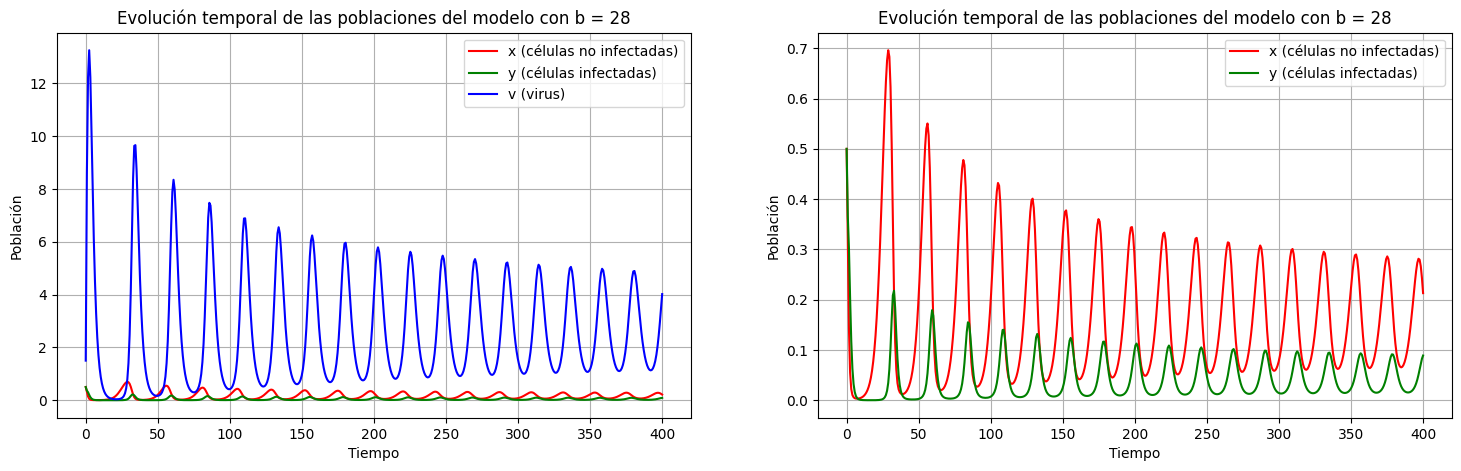

In [ ]:
# Parámetros
λ = 0.36
β = 0.11
γ = 1
δ = 0.44
K = 1
b = 28  # valor dado

# Condiciones iniciales --> X0={x=0.5,y=0.5,v=1.5}
x0 = 0.5
y0 = 0.5
v0 = 1.5
z0 = [x0, y0, v0]

# Intervalo de tiempo
t_span = (0, 400)
t_eval = np.linspace(t_span[0], t_span[1], 500)

# Integración del sistema
sol = solve_ivp(modelo3D, t_span, z0, args=(λ, K, β, γ, b, δ),
                t_eval=t_eval, method='LSODA')

# Graficar x(t) y y(t) y z(t)
plt.figure(figsize=(18,5))
plt.subplot(1, 2, 1)
plt.plot(sol.t, sol.y[0], color='red', label='x (células no infectadas)')
plt.plot(sol.t, sol.y[1], color='green', label='y (células infectadas)')
plt.plot(sol.t, sol.y[2], color='blue', label='v (virus)')
plt.xlabel('Tiempo')
plt.ylabel('Población')
plt.title(f'Evolución temporal de las poblaciones del modelo con b = {b}')
plt.legend()
plt.grid(True)

# Graficar x(t) y y(t)
plt.subplot(1, 2, 2)
plt.plot(sol.t, sol.y[0], color='red', label='x (células no infectadas)')
plt.plot(sol.t, sol.y[1], color='green', label='y (células infectadas)')
plt.xlabel('Tiempo')
plt.ylabel('Población')
plt.title(f'Evolución temporal de las poblaciones del modelo con b = {b}')
plt.legend()
plt.grid(True)
plt.show()

### 4.2 Retrato de fase del modelo 3D

Modelo 3D con b = 28
Eq1:


Eq(-0.11*v*x + 0.36*x*(-x - y + 1), 0)

Eq2:


Eq(0.11*v*x - y, 0)

Eq3:


Eq(-0.11*v*x - 0.44*v + 28*y, 0)

Con las siguintes condiciones iniciales (t=0): x[0] = 0.5, y[0] = 0.5, v[0] = 1.5 



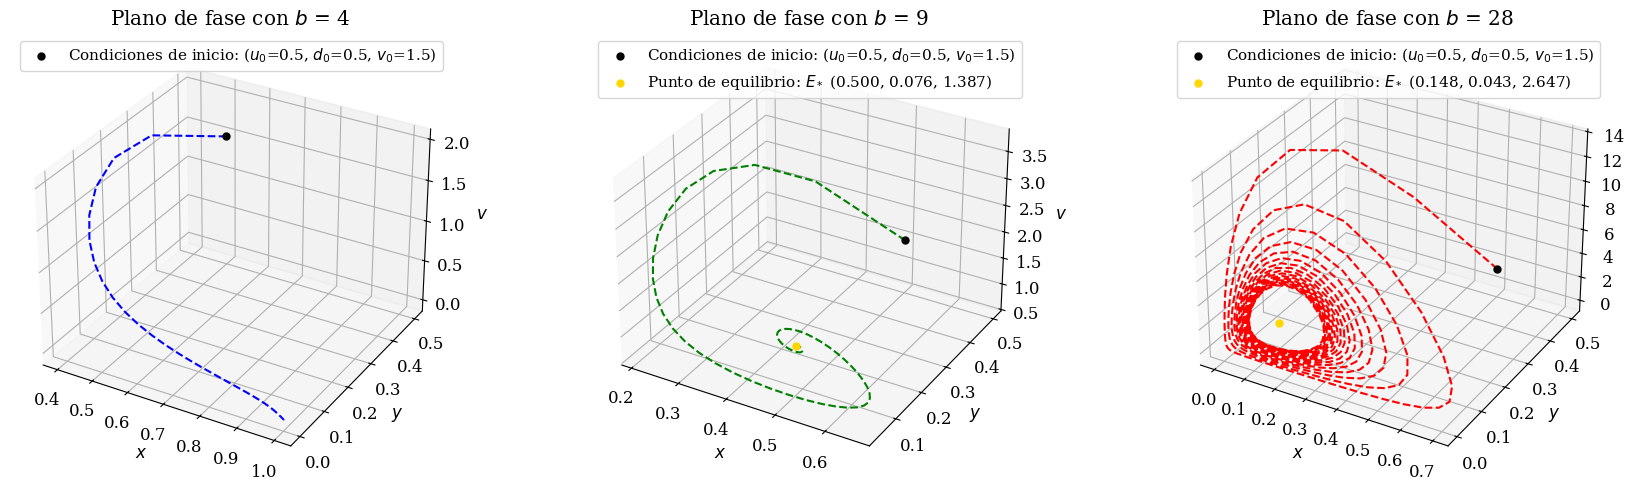

In [ ]:
# Parámetros
λ = 0.36
β = 0.11
γ = 1
δ = 0.44
K = 1
b = 28  # valor dado

# Condiciones iniciales --> X0={x=0.4,y=0.05,v=0.05}
x0 = 0.5
y0 = 0.5
v0 = 1.5
z0 = [x0, y0, v0]

# Intervalo de tiempo
t_span = (0, 400)
t_eval = np.linspace(t_span[0], t_span[1], 500)

# Integración del sistema
sol = solve_ivp(modelo3D, t_span, z0, args=(λ, K, β, γ, b, δ),
                t_eval=t_eval, method='LSODA')

# Imprimimos el modelo que se está resolviendo en concreto
print(f"Modelo 3D con b = {b}")
for i in range(3):
  print(f"Eq{i+1}:")
  display(sp.Eq(model[i], 0))
print(f"Con las siguintes condiciones iniciales (t=0): x[0] = {x0}, y[0] = {y0}, v[0] = {v0} \n")

plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = ["DejaVu Serif", "cmr10", "Computer Modern Roman"]
plt.rcParams["font.size"] = 12

b_vals_plot = [4, 9, 28]
colores     = ['blue', 'green', 'red']

def equilibrio_endemico(b_val):
    """Calcula E* = (x*, y*, v*) del modelo 3D adimensionalizado."""
    x_star = δ / (β * (b_val - 1))
    v_star = γ * λ * (K * b_val * β - K * β - δ) / (β * (K * b_val * β * γ - K * β * γ + δ * λ))
    y_star = δ * λ * (K * b_val * β - K * β - δ) / (β * (b_val - 1) * (K * b_val * β * γ - K * β * γ + δ * λ))
    return x_star, y_star, v_star

fig = plt.figure(figsize=(18, 5))

for i, (b_val, color) in enumerate(zip(b_vals_plot, colores)):

    sol = solve_ivp(
        modelo3D,
        (0, 400),
        [x0, y0, v0],
        args=(λ, K, β, γ, b_val, δ),
        t_eval=np.linspace(0, 400, 500),
        method='LSODA'
    )

    x_star, y_star, v_star = equilibrio_endemico(b_val)
    eq_biologico = (x_star > 0) and (y_star > 0) and (v_star > 0)

    ax = fig.add_subplot(1, 3, i + 1, projection='3d')

    ax.plot(sol.y[0], sol.y[1], sol.y[2], color=color, linestyle='--', lw=1.5)

    ax.scatter(x0, y0, v0, color='black', s=25,
               label=f'Condiciones de inicio: ($u_0$={x0}, $d_0$={y0}, $v_0$={v0})')

    if eq_biologico:
        ax.scatter(x_star, y_star, v_star, color='gold', s=25,
                   label=f'Punto de equilibrio: $E_*$ ({x_star:.3f}, {y_star:.3f}, {v_star:.3f})')

    ax.set_title(f'Plano de fase con $b$ = {b_val}')
    ax.set_xlabel('$x$')
    ax.set_ylabel('$y$')
    ax.set_zlabel('$v$')
    ax.legend(fontsize=11)
    ax.grid(True)

plt.tight_layout()
plt.savefig("retratos_fase_3D.pdf", bbox_inches="tight")
plt.show()

Modelo 3D con b = 28
Eq1:


Eq(-0.11*v*x + 0.36*x*(-x - y + 1), 0)

Eq2:


Eq(0.11*v*x - y, 0)

Eq3:


Eq(-0.11*v*x - 0.44*v + 28*y, 0)

Con las siguintes condiciones iniciales (t=0): x[0] = 0.12, y[0] = 0.046, v[0] = 0.01 



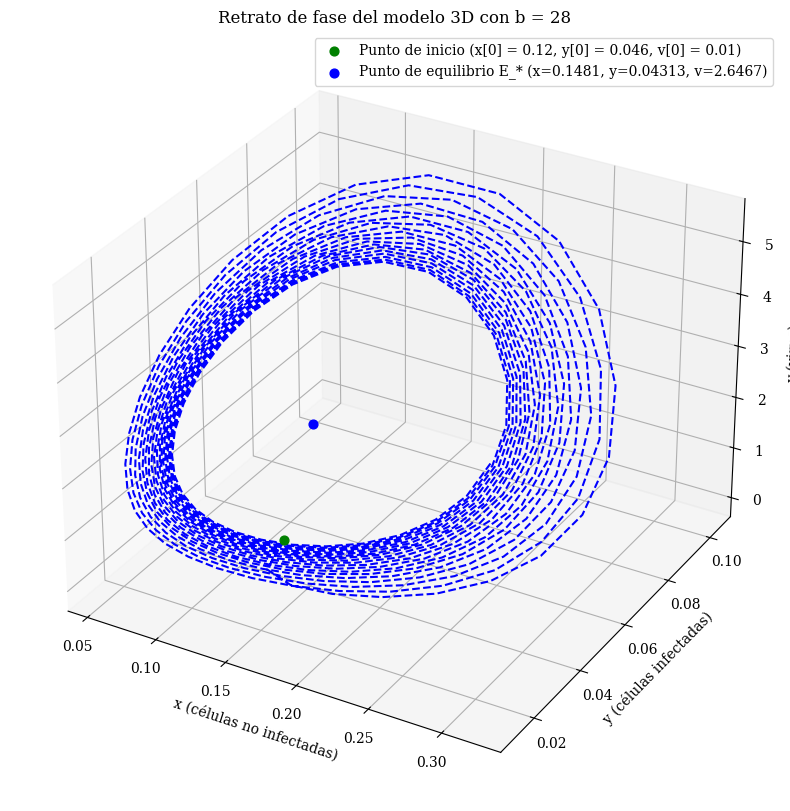

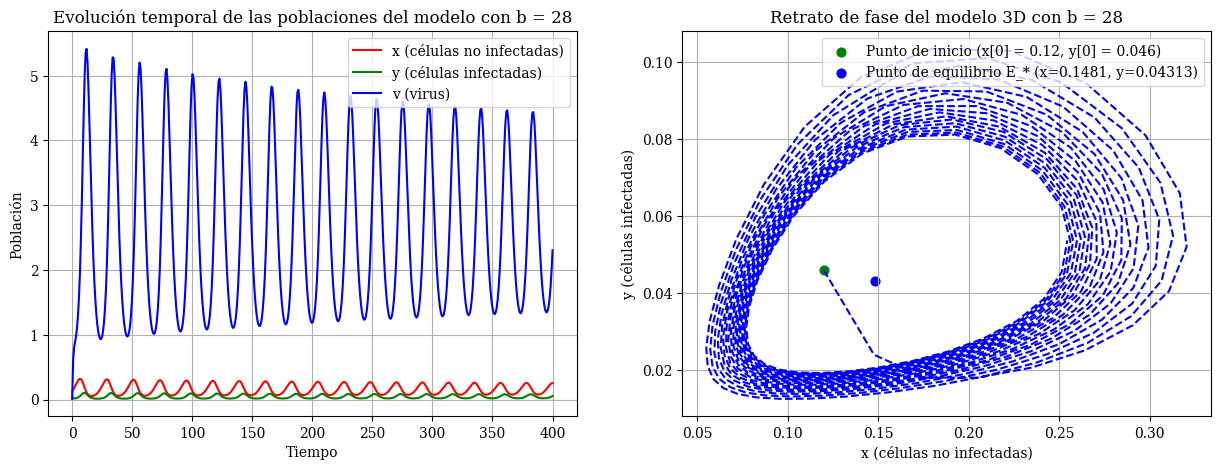

In [ ]:
# Parámetros
λ = 0.36
β = 0.11
γ = 1
δ = 0.44
K = 1
b = 28  # valor dado

# Condiciones iniciales --> X0={x=0.12,y=0.046,v=0.01}
x0 = 0.12
y0 = 0.046
v0 = 0.01
z0 = [x0, y0, v0]

# Intervalo de tiempo
t_span = (0, 400)
t_eval = np.linspace(t_span[0], t_span[1], 500)

# Integración del sistema
sol = solve_ivp(modelo3D, t_span, z0, args=(λ, K, β, γ, b, δ),
                t_eval=t_eval, method='LSODA')

# Imprimimos el modelo que se está resolviendo en concreto
print(f"Modelo 3D con b = {b}")
for i in range(3):
  print(f"Eq{i+1}:")
  display(sp.Eq(model[i], 0))
print(f"Con las siguintes condiciones iniciales (t=0): x[0] = {x0}, y[0] = {y0}, v[0] = {v0} \n")

fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

# Graficar trayectoria
ax.plot(sol.y[0], sol.y[1], sol.y[2], color='blue',linestyle='--')

# Añadir puntos --> condición de inicio y E_*
ax.scatter(x0, y0, v0, color='green', s=40, label=f'Punto de inicio (x[0] = {x0}, y[0] = {y0}, v[0] = {v0})')
ax.scatter(0.1481, 0.04313, 2.6467, color='blue', s=40, label='Punto de equilibrio E_* (x=0.1481, y=0.04313, v=2.6467)')

# Etiquetas y título
ax.set_xlabel('x (células no infectadas)')
ax.set_ylabel('y (células infectadas)')
ax.set_zlabel('v (virus)')
plt.title(f'Retrato de fase del modelo 3D con b = {b}')
ax.legend()
plt.show()

# Gráfica en 2D
plt.figure(figsize=(15, 5))
plt.subplot(1, 2, 1)
plt.plot(sol.t, sol.y[0], color='red', label='x (células no infectadas)')
plt.plot(sol.t, sol.y[1], color='green', label='y (células infectadas)')
plt.plot(sol.t, sol.y[2], color='blue', label='v (virus)')
plt.xlabel('Tiempo')
plt.ylabel('Población')
plt.title(f'Evolución temporal de las poblaciones del modelo con b = {b}')
plt.legend()
plt.grid(True)

# Second subplot for the 2D phase portrait
ax = plt.subplot(1, 2, 2)
ax.plot(sol.y[0], sol.y[1], color='blue',linestyle='--')
ax.scatter(x0, y0, color='green', s=40, label=f'Punto de inicio (x[0] = {x0}, y[0] = {y0})')
ax.scatter(0.1481, 0.04313,color='blue', s=40, label='Punto de equilibrio E_* (x=0.1481, y=0.04313)')
ax.set_xlabel('x (células no infectadas)')
ax.set_ylabel('y (células infectadas)')
plt.title(f'Retrato de fase del modelo 3D con b = {b}')
plt.grid(True)
ax.legend(loc='upper right')
plt.show()

### 4.3 Diagrama de bifurcación x vs. b

In [ ]:
import sympy as sp

# 1. Definición de Símbolos
x, y, v = sp.symbols('x, y, v')
λ, δ, β, b_simb, K, γ = sp.symbols('lambda, delta, beta, b, K, gamma')

# 2. Parámetros Fijos
params_fijos = {
    λ: 0.36,
    δ: 0.44,
    β: 0.11,
    K: 1.0,
    γ: 1.0
}

# 3. Definición del Equilibrio Endémico E* SIMBÓLICO
# Utilizamos las expresiones simbólicas de E* que dependen de b_simb y los parámetros:
x_star = δ / (β * (b_simb - 1))
v_star = (γ * λ * (K * b_simb * β - K * β - δ)) / (β * (K * b_simb * β * γ - K * β * γ + δ * λ))
y_star = (β * x_star * v_star) / γ

puntos_fijos_simb_correcto = {x: x_star, y: y_star, v: v_star}


# 4. Crear el modelo y Jacobiana (asumiendo que 'modelo3D_sym' es correcto)
model_sym_raw = modelo3D_sym(0, [x, y, v], λ, K, β, γ, b_simb, δ)
J_hopf = sp.Matrix(model_sym_raw).jacobian((x, y, v))

# 5. Sustituir el punto de equilibrio (J_end depende de los parámetros y b_simb)
J_end = J_hopf.subs(puntos_fijos_simb_correcto) # <-- Usamos el punto simbólico correcto

# 6. Sustituir los parámetros fijos (solo queda b_simb)
J_hopf_2 = J_end.subs(params_fijos)

# La matriz J_hopf_2 ahora contendrá expresiones algebraicas complejas
# que solo dependen de 'b' (b_simb).
display(J_hopf_2)

Matrix([
[-0.36*(0.11*b - 0.55)/(0.11*b + 0.0484) - 0.5184*(0.11*b - 0.55)/((0.11*b + 0.0484)*(b - 1)) + 0.36 - 2.88/(b - 1), -1.44/(b - 1),        -0.44/(b - 1)],
[                                                                            0.36*(0.11*b - 0.55)/(0.11*b + 0.0484),          -1.0,         0.44/(b - 1)],
[                                                                           -0.36*(0.11*b - 0.55)/(0.11*b + 0.0484),         1.0*b, -0.44 - 0.44/(b - 1)]])

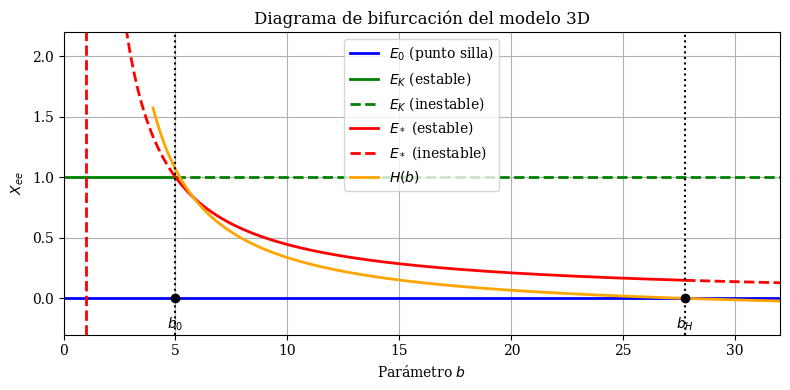

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.linalg import det
from matplotlib.lines import Line2D

# --- 1. PARÁMETROS Y CONFIGURACIÓN ---
lam = 0.36
beta = 0.11
delta = 0.44
K = 1.0
gamma = 1.0

b0 = 5.0
bH = 27.7664

#  {v: γ*λ*(K*b*β - K*β - δ)/(β*(K*b*β*γ - K*β*γ + δ*λ)), x: δ/(β*(b - 1)), y: δ*λ*(K*b*β - K*β - δ)/(β*(b - 1)*(K*b*β*γ - K*β*γ + δ*λ))}

# --- 2. FUNCIONES ---
def x_star_endemic(b_val):
    # x* = delta / (beta * (b - 1))
    # Matemáticamente existe para b != 1
    return delta / (beta * (b_val - 1))

def calculate_Hb(b_vals):
    """
    Calcula la curva H(b) para el criterio de Hopf/Hurwitz.
    Utiliza J_hopf_2 (simbólica) y sustituye b en cada paso.
    """
    H_vals = []

    for b_val in b_vals:
        # 1. Verificar la condición biológica (asumiendo que x_star_endemic usa b_val)
        x = x_star_endemic(b_val)

        if x <= 0:
             H_vals.append(np.nan)
             continue

        # 2. Sustituir el valor numérico actual de b_val en la Jacobiana simbólica
        J_simb_sustituida = J_hopf_2.subs(b_simb, b_val)

        # 3. Convertir la matriz de SymPy a un array numérico de NumPy
        J_num = np.array(J_simb_sustituida, dtype=float)

        # 4. Criterio de Routh-Hurwitz
        tr = np.trace(J_num)
        det_j = det(J_num)

        # Suma de menores principales de 2x2 (a1)
        m1 = J_num[1,1]*J_num[2,2] - J_num[1,2]*J_num[2,1] # M_00
        m2 = J_num[0,0]*J_num[2,2] - J_num[0,2]*J_num[2,0] # M_11
        m3 = J_num[0,0]*J_num[1,1] - J_num[0,1]*J_num[1,0] # M_22
        sum_m2 = m1 + m2 + m3

        # Coeficientes: a2 = -Tr(J), a1 = Sum_M2, a0 = -Det(J)
        a1 = sum_m2
        a2 = -tr
        a0 = -det_j

        # Condición de Hopf: H(b) = a1*a2 - a0
        Hb = a1 * a2 - a0

        H_vals.append(Hb)

    return np.array(H_vals)

# --- 3. GENERACIÓN DE DATOS ---
# Generamos rangos específicos para evitar la singularidad en b=1

# Rango 1: 0 a 1 (No graficamos E* aquí porque es negativo)
# Rango 2: 1.1 a 5 (E* inestable, rama izquierda)
b_range_left = np.linspace(1.05, b0, 200)
x_left = x_star_endemic(b_range_left)

# Rango 3: 5 a bH (E* estable)
b_range_mid = np.linspace(b0, bH, 200)
x_mid = x_star_endemic(b_range_mid)

# Rango 4: bH a 32 (E* inestable, rama derecha)
b_range_right = np.linspace(bH, 32, 100)
x_right = x_star_endemic(b_range_right)

# Rango completo para H(b) (Lo graficamos desde b0 = 5 --> Sentido biológico)
b_full = np.linspace(4, 32, 300)
Hb_curve = calculate_Hb(b_full)


# --- 4. GRAFICA Y ESTÉTICA ---
plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = ["DejaVu Serif", "cmr10", "Computer Modern Roman"]
plt.rcParams["font.size"] = 10

fig, ax = plt.subplots(figsize=(8, 4))

lw = 2.0

# A) Líneas horizontales (E0 y EK)
ax.hlines(0, 0, 32, colors='blue',   linewidth=lw, linestyle='-')   # 1º → azul
ax.hlines(1, 0,  b0, colors='green', linewidth=lw, linestyle='-')   # 2º → verde
ax.hlines(1, b0, 32, colors='green', linewidth=lw, linestyle='--')  # 2º (inestable) → verde --

# B) Curva endémica E*
ax.plot(b_range_left,  x_left,  color='red',    linestyle='--', linewidth=lw)  # 3º inestable → rojo --
ax.plot(b_range_mid,   x_mid,   color='red',    linestyle='-',  linewidth=lw)  # 3º estable   → rojo
ax.plot(b_range_right, x_right, color='red',    linestyle='--', linewidth=lw)  # 3º inestable → rojo --

# C) Curva H(b)
ax.plot(b_full, Hb_curve, color='orange', linewidth=lw)                        # 4º → naranja

# D) Líneas verticales y puntos
ax.axvline(b0, color='black', linestyle=':', linewidth=1.5)
ax.axvline(bH, color='black', linestyle=':', linewidth=1.5)
ax.axvline(1,  color='red',   linestyle='--', linewidth=lw)
ax.plot(b0, 0, 'ko', markersize=6, zorder=10)
ax.plot(bH, 0, 'ko', markersize=6, zorder=10)

ax.text(b0, -0.25, '$b_0$', ha='center')
ax.text(bH, -0.25, '$b_H$', ha='center')

# E) Ajustes de ejes
ax.set_xlim(0, 32)
ax.set_ylim(-0.3, 2.2)

for spine in ax.spines.values():
    spine.set_visible(True)

ax.set_title('Diagrama de bifurcación del modelo 3D')
ax.set_xlabel('Parámetro $b$')
ax.set_ylabel('$X_{ee}$')
ax.grid(True)

# F) Leyenda
legend_elements = [
    Line2D([0], [0], color='blue',   lw=lw,          label='$E_0$ (punto silla)'),
    Line2D([0], [0], color='green',  lw=lw,           label='$E_K$ (estable)'),
    Line2D([0], [0], color='green',  lw=lw, ls='--',  label='$E_K$ (inestable)'),
    Line2D([0], [0], color='red',    lw=lw,            label='$E_*$ (estable)'),
    Line2D([0], [0], color='red',    lw=lw, ls='--',   label='$E_*$ (inestable)'),
    Line2D([0], [0], color='orange', lw=lw,            label='$H(b)$'),
]
ax.legend(handles=legend_elements)

plt.tight_layout()
plt.savefig("diagrama_bifurcacion.pdf", bbox_inches="tight")
plt.show()

### 4.4 Diagrama de estabilidad ($\beta$ vs. b)

In [ ]:
# 1. Definición de Símbolos
x, y, v = sp.symbols('x, y, v')
λ, δ, β_simb, b_simb, K, γ = sp.symbols('lambda, delta, beta, b, K, gamma')

# 2. Parámetros Fijos
params_fijos = {
    λ: 0.36,
    δ: 0.44,
    K: 1.0,
    γ: 1.0
}

# 3. Definición del Equilibrio Endémico E* SIMBÓLICO
# Utilizamos las expresiones simbólicas de E* que dependen de b_simb y los parámetros:
x_star = δ / (β_simb * (b_simb - 1))
v_star = (γ * λ * (K * b_simb * β_simb - K * β_simb - δ)) / (β_simb * (K * b_simb * β_simb * γ - K * β_simb * γ + δ * λ))
y_star = (β_simb * x_star * v_star) / γ

puntos_fijos_simb_correcto = {x: x_star, y: y_star, v: v_star}


# 4. Crear el modelo y Jacobiana (asumiendo que 'modelo3D_sym' es correcto)
model_sym_raw = modelo3D_sym(0, [x, y, v], λ, K, β_simb, γ, b_simb, δ)
J_h = sp.Matrix(model_sym_raw).jacobian((x, y, v))

# 5. Sustituir el punto de equilibrio (J_end depende de los parámetros y b_simb)
J_e = J_h.subs(puntos_fijos_simb_correcto) # <-- Usamos el punto simbólico correcto

# 6. Sustituir los parámetros fijos (solo queda b_simb)
J_h_2 = J_e.subs(params_fijos)

# La matriz J_hopf_2 ahora contendrá expresiones algebraicas complejas
# que solo dependen de 'b' (b_simb).
display(J_h_2)

Matrix([
[-0.36*(1.0*b*beta - 1.0*beta - 0.44)/(1.0*b*beta - 1.0*beta + 0.1584) + 0.36 - 0.057024*(1.0*b*beta - 1.0*beta - 0.44)/(beta*(b - 1)*(1.0*b*beta - 1.0*beta + 0.1584)) - 0.3168/(beta*(b - 1)), -0.1584/(beta*(b - 1)),        -0.44/(b - 1)],
[                                                                                                                          0.36*(1.0*b*beta - 1.0*beta - 0.44)/(1.0*b*beta - 1.0*beta + 0.1584),                   -1.0,         0.44/(b - 1)],
[                                                                                                                         -0.36*(1.0*b*beta - 1.0*beta - 0.44)/(1.0*b*beta - 1.0*beta + 0.1584),                  1.0*b, -0.44 - 0.44/(b - 1)]])

/tmp/ipykernel_3093/141245269.py:145: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


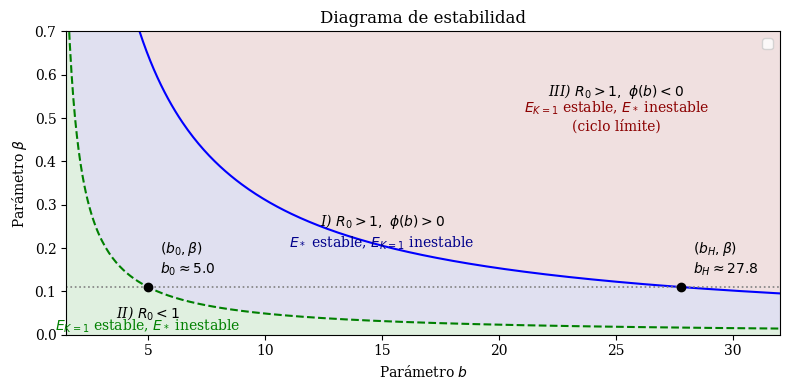

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import brentq
from numpy.linalg import det
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

# --- 1. PARÁMETROS Y FUNCIONES ---
lam = 0.36
delta = 0.44
K = 1.0
gamma = 1.0

def get_beta_existence(b_val):
    if b_val <= 1.01: return np.nan
    return delta / (K * (b_val - 1))

def hopf_criterion(beta_val, b_val):
    # Condición de Existencia (E* > 0)
    # Usamos los valores numéricos 'delta', 'K' y 'lam' definidos globalmente.
    x = delta / (beta_val * (b_val - 1))

    if x <= 0 or x > K:
        return -100.0 # Valor que asegura que brentq no lo use como raíz

    # 1. Sustituir ambos símbolos con sus valores numéricos
    J_simb_sustituida = J_h_2.subs({
        β_simb: beta_val,
        b_simb: b_val
    })

    # 2. Convertir a array numérico
    J_num = np.array(J_simb_sustituida, dtype=float)

    # 3. Cálculo del Criterio de Hurwitz
    tr = np.trace(J_num)
    det_j = det(J_num)

    # Suma de menores principales de 2x2 (a1)
    m1 = J_num[1,1]*J_num[2,2] - J_num[1,2]*J_num[2,1]
    m2 = J_num[0,0]*J_num[2,2] - J_num[0,2]*J_num[2,0]
    m3 = J_num[0,0]*J_num[1,1] - J_num[0,1]*J_num[1,0]
    sum_m2 = m1 + m2 + m3

    # H(β, b) = a1*a2 - a0
    Hb = sum_m2 * (-tr) - (-det_j)

    return Hb

def get_beta_hopf_curve(b_vals):
    beta_hopf = []
    for b in b_vals:
        try:
            beta_min = get_beta_existence(b)
            if np.isnan(beta_min) or beta_min >= 0.8:
                beta_hopf.append(np.nan)
                continue
            root = brentq(hopf_criterion, beta_min + 0.001, 1.5, args=(b,))
            beta_hopf.append(root)
        except: beta_hopf.append(np.nan)
    return np.array(beta_hopf)

# --- 2. GENERACIÓN DE DATOS Y PUNTOS CRÍTICOS ---
b_vals = np.linspace(1.5, 32, 400)
beta_exist = np.array([get_beta_existence(b) for b in b_vals])
beta_hopf = get_beta_hopf_curve(b_vals)

my_beta = 0.11
# Calcular b0 y bH exactos para beta=0.11
# b0 es cuando beta = delta / (K*(b-1))
b0_val = (delta / (K * my_beta)) + 1
# bH se busca numéricamente
try:
    bH_val = brentq(hopf_criterion, b0_val + 1, 50, args=(my_beta,))
except: bH_val =  27.7664

# --- 3. GRAFICADO BASE (Regiones) ---
plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = ["DejaVu Serif", "cmr10", "Computer Modern Roman"]
plt.rcParams["font.size"] = 10

fig, ax = plt.subplots(figsize=(8, 4))

# Colores de fondo de regiones
c_reg1 = '#E0F0E0'
c_reg2 = '#E0E0F0'
c_reg3 = '#F0E0E0'

lw_bd = 1.5

# Líneas de frontera
ax.plot(b_vals, beta_exist, color='green', ls='--', lw=lw_bd)
ax.plot(b_vals, beta_hopf,  color='blue',  ls='-',  lw=lw_bd)

# Rellenos de regiones
ax.fill_between(b_vals, 0, beta_exist, color=c_reg1, alpha=1)
mask_hopf = ~np.isnan(beta_hopf)
beta_hopf_clean = np.copy(beta_hopf)
beta_hopf_clean[~mask_hopf] = 100
ax.fill_between(b_vals, beta_exist, beta_hopf_clean,
                where=(beta_hopf_clean > beta_exist), color=c_reg2, alpha=1, interpolate=True)
ax.fill_between(b_vals, beta_hopf_clean, 1.0,
                where=(beta_hopf_clean < 1.0), color=c_reg3, alpha=1, interpolate=True)

# Línea horizontal para beta de referencia
ax.axhline(my_beta, color='gray', linestyle=':', linewidth=1.2)

# Puntos b0 y bH
ax.plot(b0_val, my_beta, 'ko', markersize=6, zorder=10)
ax.text(b0_val + 0.5, my_beta + 0.02,
        f'$(b_0, \\beta)$\n$b_0 \\approx {b0_val:.1f}$', va='bottom')

ax.plot(bH_val, my_beta, 'ko', markersize=6, zorder=10)
ax.text(bH_val + 0.5, my_beta + 0.02,
        f'$(b_H, \\beta)$\n$b_H \\approx {bH_val:.1f}$', va='bottom')

# Textos de regiones
ax.text(5,  0.04,  'II) $R_0 < 1$',                                       ha='center', style='italic')
ax.text(5,  0.010, '$E_{K=1}$ estable, $E_*$ inestable',                  ha='center', color='green')
ax.text(15, 0.25,  'I) $R_0 > 1,\\ \\phi(b) > 0$',                        ha='center', style='italic')
ax.text(15, 0.20,  '$E_*$ estable, $E_{K=1}$ inestable',                  ha='center', color='darkblue')
ax.text(25, 0.55,  'III) $R_0 > 1,\\ \\phi(b) < 0$',                      ha='center', style='italic')
ax.text(25, 0.47,  '$E_{K=1}$ estable, $E_*$ inestable\n(ciclo límite)',  ha='center', color='darkred')

# Ejes
ax.set_xlim(1.5, 32)
ax.set_ylim(0, 0.7)
ax.set_xlabel('Parámetro $b$')
ax.set_ylabel('Parámetro $\\beta$')
ax.set_title('Diagrama de estabilidad')
ax.grid(False)

# Recuadro completo (caja)
for spine in ax.spines.values():
    spine.set_visible(True)

# Leyenda
legend_elements = [
    Line2D([0], [0], color='green', ls='--', lw=lw_bd, label='Frontera $R_0=1$ (transcrítica)'),
    Line2D([0], [0], color='blue',  ls='-',  lw=lw_bd, label='Frontera $\\phi(b)=0$ (Hopf)'),
    Patch(facecolor=c_reg1, label='Zona II: extinción viral'),
    Patch(facecolor=c_reg2, label='Zona I: endémico estable'),
    Patch(facecolor=c_reg3, label='Zona III: oscilaciones'),
]
ax.legend()

plt.tight_layout()
plt.savefig("diagrama_estabilidad.pdf", bbox_inches="tight")
plt.show()